<a href="https://colab.research.google.com/github/suryansh24-coder/Machine-Learning-Journey/blob/main/Function_Transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv('traind.csv',usecols=['Age','Fare','Survived'])

In [3]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
df.isnull().sum()

,0
Survived,0
Age,177
Fare,0


In [5]:
df.fillna(df['Age'].mean(),inplace=True)

In [6]:
df['Age']

,Age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


In [7]:
X = df.iloc[:,1:3]
y = df.iloc[:,0]

In [8]:
X_train ,X_test ,y_train ,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

/tmp/ipykernel_828/2467769593.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


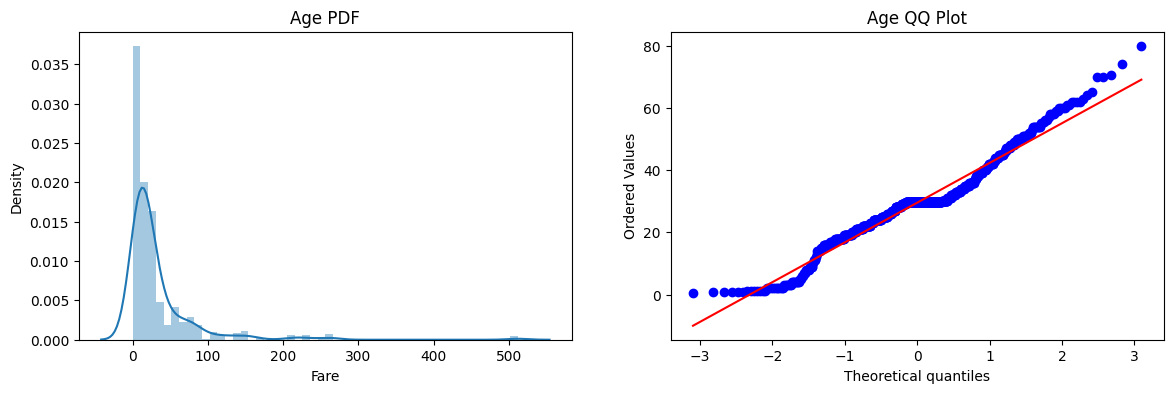

In [12]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'],plot=plt , dist="norm")
plt.title('Age QQ Plot')

plt.show()

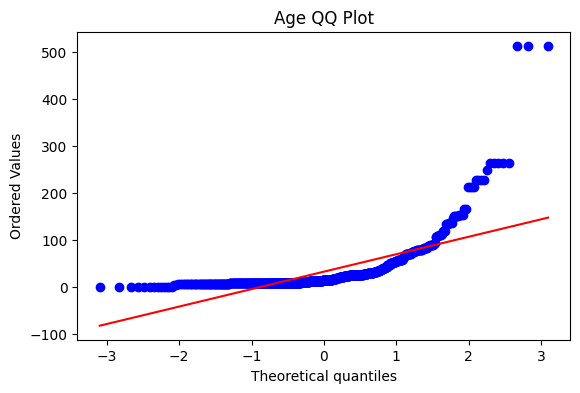

In [13]:
plt.figure(figsize=(14,4))
plt.subplot(122)
stats.probplot(X_train['Fare'],dist='norm',plot=plt)
plt.title('Age QQ Plot')

plt.show()

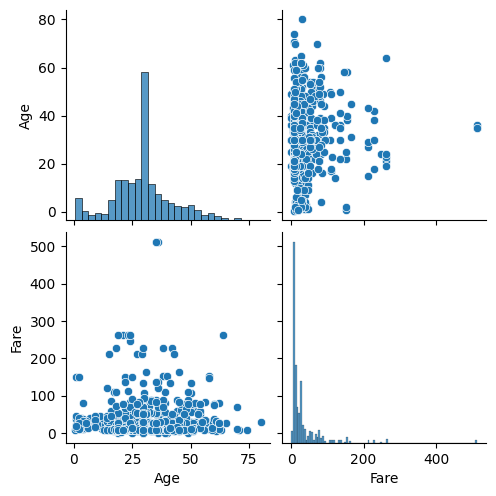

In [15]:
sns.pairplot(X_train)

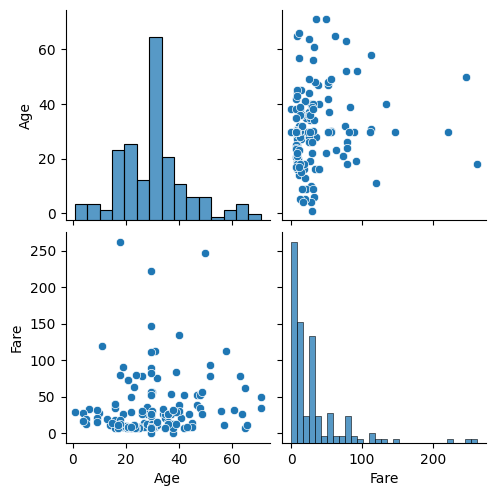

In [16]:
sns.pairplot(X_test)

In [17]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [21]:
clf.fit(X_train , y_train)
clf2.fit(X_train , y_train)

y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

print("Accuracy LR", accuracy_score(y_test,y_pred))
print("Accuracy DT", accuracy_score(y_test,y_pred1))

Accuracy LR 0.6480446927374302
Accuracy DT 0.6536312849162011


In [22]:
trf = FunctionTransformer(np.log1p)

In [31]:
X_train_Transformed = trf.fit_transform(X_train)
X_testtransformed = trf.transform(X_test)


In [32]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_Transformed  , y_train)
clf2.fit(X_train_Transformed , y_train)

y_pred = clf.predict(X_testtransformed)
y_pred1 = clf2.predict(X_testtransformed)

print("Accuracy LR", accuracy_score(y_test,y_pred))
print("Accuracy DT", accuracy_score(y_test,y_pred1))

Accuracy LR 0.6815642458100558
Accuracy DT 0.6759776536312849


In [36]:
X_tansformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR", np.mean(cross_val_score(clf , X_tansformed , y ,scoring='accuracy',cv=10)))
print("DT", np.mean(cross_val_score(clf2 , X_tansformed , y ,scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.6566167290886391


/tmp/ipykernel_828/4269217160.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


Text(0.5, 1.0, 'Age PDF')

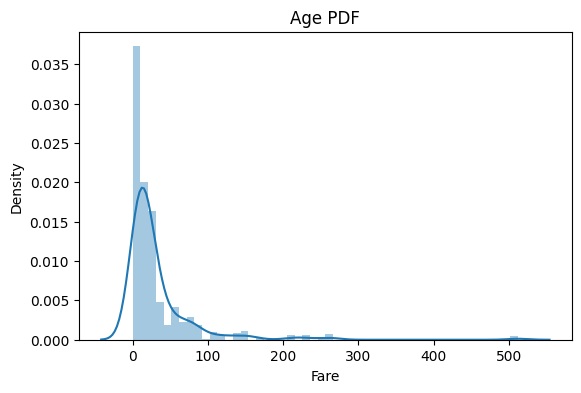

In [37]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title('Age PDF')

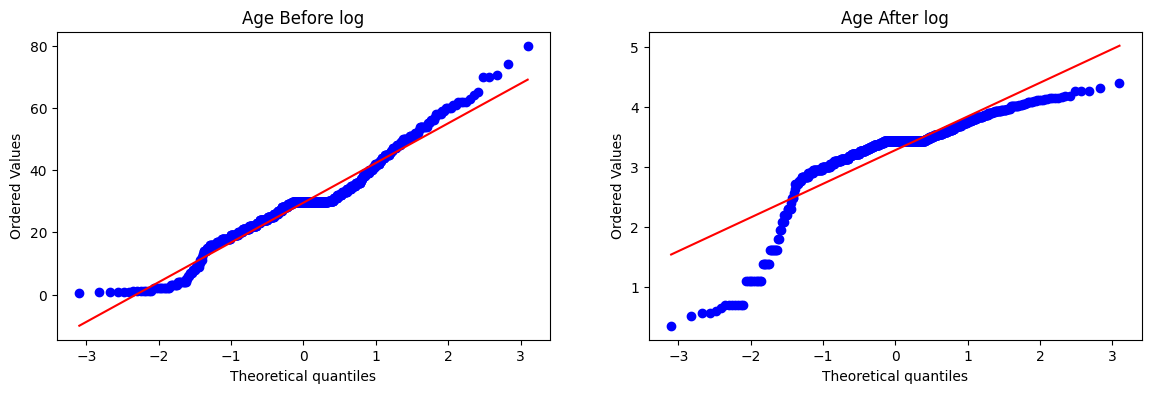

In [38]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Age'],plot=plt , dist="norm")
plt.title('Age Before log')

plt.subplot(122)
stats.probplot(np.log1p(X_train['Age']),plot=plt  , dist="norm")
plt.title('Age After log')
plt.show()


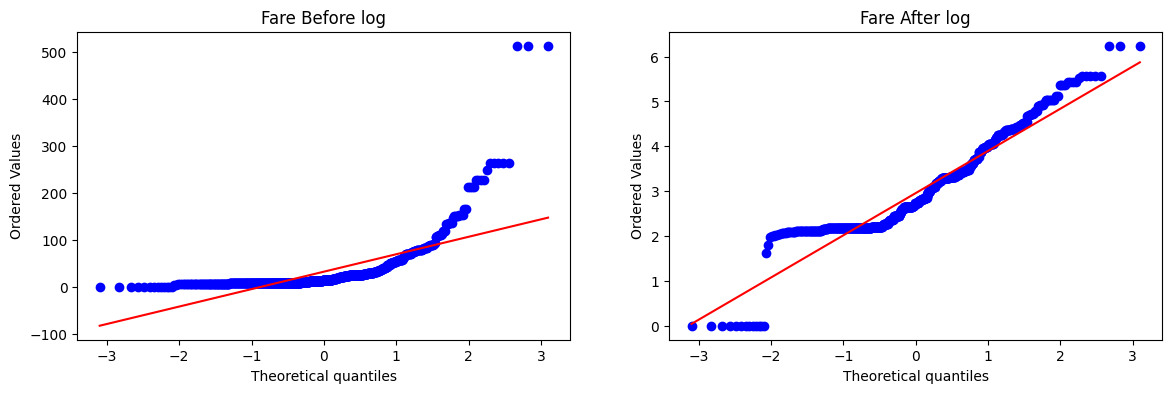

In [39]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Fare'],plot=plt , dist="norm")
plt.title('Fare Before log')

plt.subplot(122)
stats.probplot(np.log1p(X_train['Fare']),plot=plt  , dist="norm")
plt.title('Fare After log')
plt.show()


In [41]:
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')
X_train_Transformed2 = trf2.fit_transform(X_train)
X_testtransformed2 = trf2.transform(X_test)


In [42]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_Transformed2  , y_train)
clf2.fit(X_train_Transformed2 , y_train)

y_pred = clf.predict(X_testtransformed2)
y_pred1 = clf2.predict(X_testtransformed2)

print("Accuracy LR", accuracy_score(y_test,y_pred))
print("Accuracy DT", accuracy_score(y_test,y_pred1))

Accuracy LR 0.6703910614525139
Accuracy DT 0.659217877094972


In [46]:
X_transformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR", np.mean(cross_val_score(clf , X_transformed2 , y ,scoring='accuracy',cv=10)))
print("DT", np.mean(cross_val_score(clf2 , X_transformed2 , y ,scoring='accuracy',cv=10)))

LR 0.6712609238451936
DT 0.6588389513108613


In [47]:
def apply_transform(transform) :
  X = df.iloc[:,1:3]
  y = df.iloc[:,0]

  trf = ColumnTransformer([('log', FunctionTransformer(transform),['Fare'])] , remainder='passthrough')
  X_trans = trf.fit_transform(X)

  clf = LogisticRegression()
  print('Accuracy' , np.mean(cross_val_score(clf , X_trans , y ,scoring='accuracy',cv=10)))

  plt.figure(figsize=(14,4))
  plt.subplot(121)
  stats.probplot(X['Fare'],plot=plt , dist="norm")
  plt.title('Fare Before log')

  plt.subplot(122)
  stats.probplot(X_trans[:,0] , dist="norm" , plot=plt)
  plt.title("Fare After Transform")

  plt.show()

Accuracy 0.6589013732833957


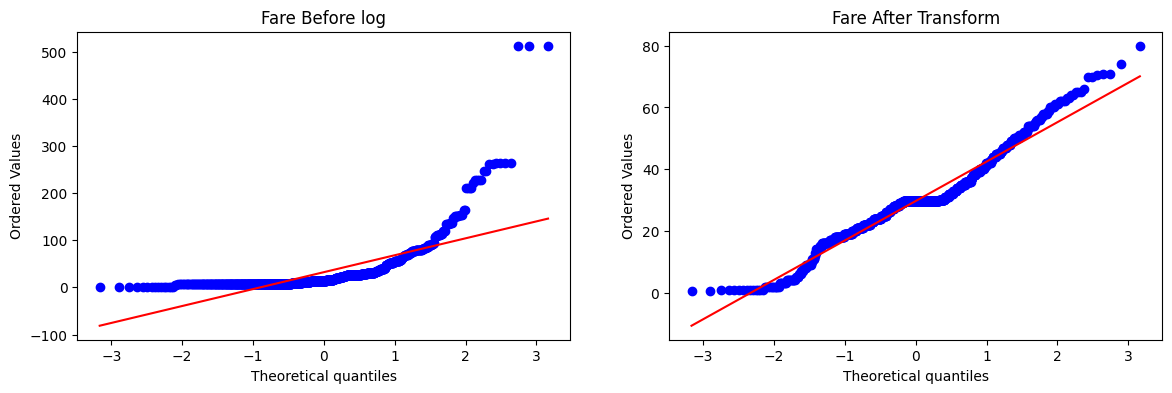

In [48]:
apply_transform(lambda x : X)

Accuracy 0.6431335830212235


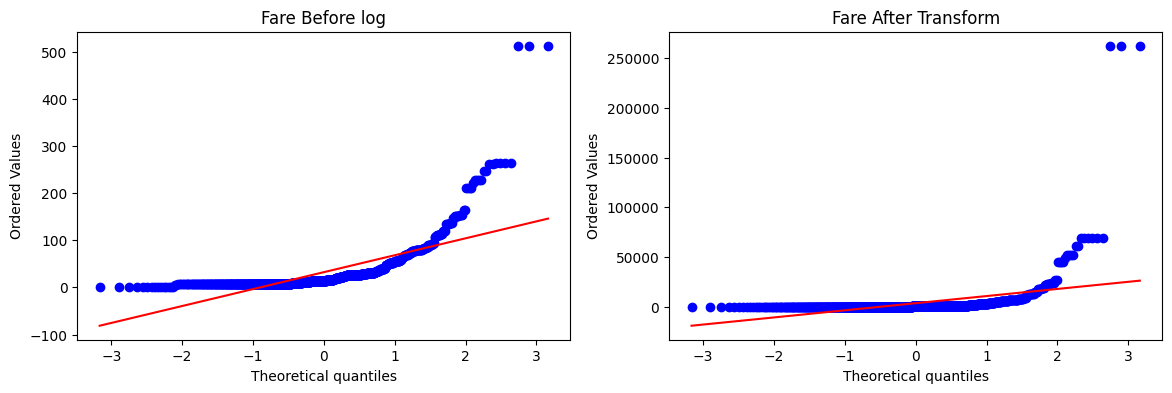

In [49]:
apply_transform(lambda x : x**2)

Accuracy 0.6262796504369538


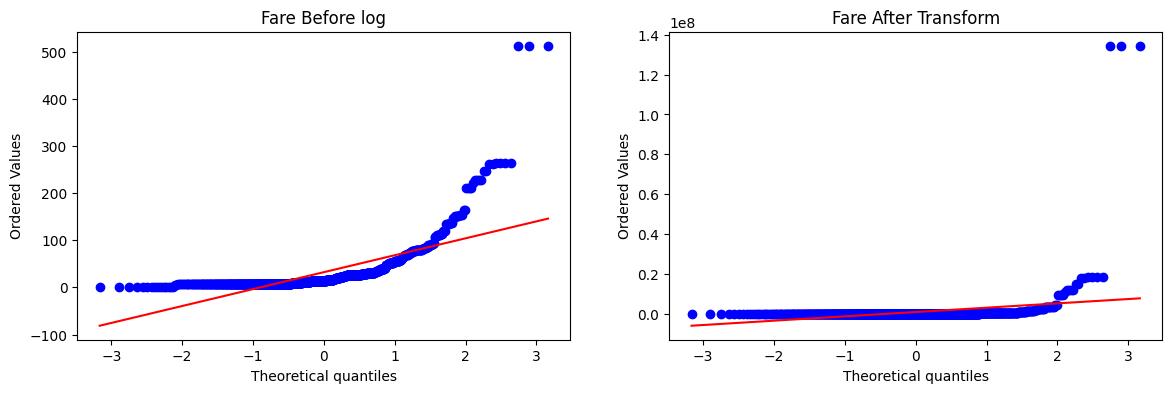

In [50]:
apply_transform(lambda x : x**3)

Accuracy 0.6589013732833957


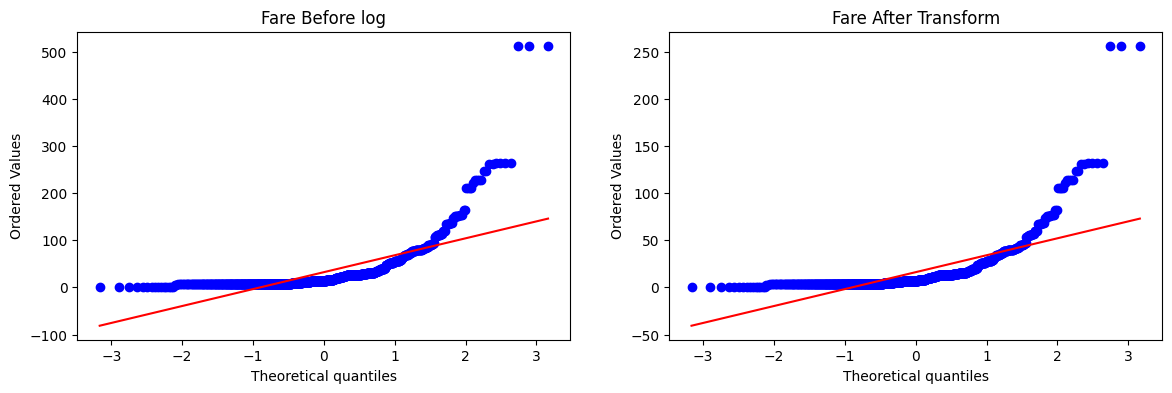

In [51]:
apply_transform(lambda x : x**1/2)

Accuracy 0.61729088639201


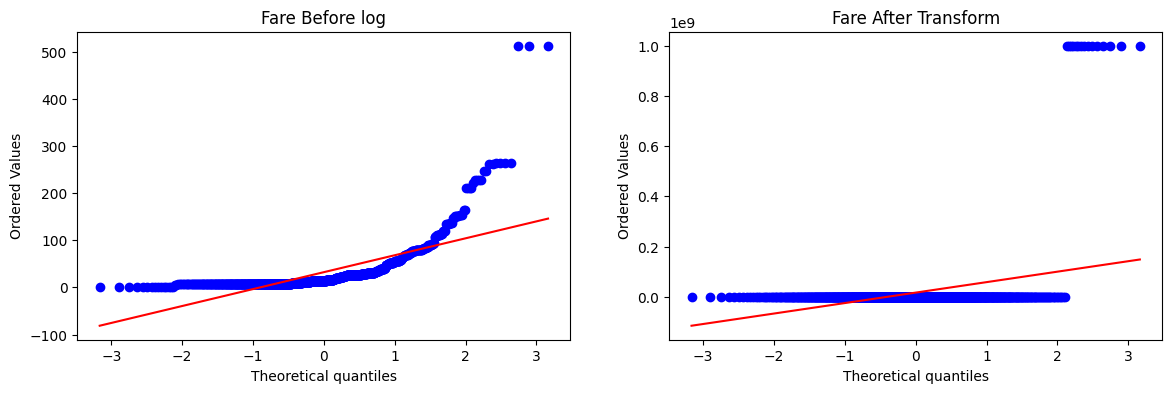

In [53]:
apply_transform(lambda x : 1/(x+0.000000001))